# Functions needed for research

In [74]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import struct

CAMERA_MODELS = {
    0: ("SIMPLE_PINHOLE", 3), # f, cx, cy
    1: ("PINHOLE", 4),        # fx, fy, cx, cy (Undistortion 후 주로 사용됨)
    2: ("SIMPLE_RADIAL", 4),  # f, cx, cy, k
    3: ("RADIAL", 5),         # f, cx, cy, k1, k2
    4: ("OPENCV", 8),         # fx, fy, cx, cy, k1, k2, p1, p2 (기존 모델)
    5: ("OPENCV_FISHEYE", 8), 
    6: ("FULL_OPENCV", 12)
}

def readCamerasBin(file_path):
    cameras = {}
    with open(file_path, "rb") as fid:
        # 1. 카메라 개수 읽기
        num_cameras = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(num_cameras):
            # 2. Camera ID, Model ID
            camera_id = struct.unpack("<I", fid.read(4))[0]
            model_id = struct.unpack("<I", fid.read(4))[0]
            
            # 3. Width, Height
            width = struct.unpack("<Q", fid.read(8))[0]
            height = struct.unpack("<Q", fid.read(8))[0]
            
            # 4. Model ID에 따라 파라미터 개수를 동적으로 결정
            if model_id not in CAMERA_MODELS:
                raise ValueError(f"지원하지 않는 카메라 모델 ID입니다: {model_id}")
            
            model_name, num_params = CAMERA_MODELS[model_id]
            
            # 5. Parameters 읽기
            params = struct.unpack("<" + "d" * num_params, fid.read(8 * num_params))
            
            cameras[camera_id] = {
                "model_name": model_name,
                "model_id": model_id,
                "width": width,
                "height": height,
                "params": params
            }
    return cameras

def readColmapImagesBin(file_path):
    images = {}
    
    with open(file_path, "rb") as fid:
        # The first 8 bytes contain the total number of images
        numRegImages = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(numRegImages):
            # Read fixed-length camera pose and IDs (64 bytes total)
            # i = int (4 bytes), d = double (8 bytes)
            binaryImageProperties = struct.unpack("<idddddddi", fid.read(64))
            
            imageId = binaryImageProperties[0]
            qvec = np.array(binaryImageProperties[1:5])  # Quaternion (w, x, y, z)
            tvec = np.array(binaryImageProperties[5:8])  # Translation (x, y, z)
            cameraId = binaryImageProperties[8]
            
            # Read variable-length image name (stops at null byte \x00)
            imageName = b""
            char = fid.read(1)
            while char != b"\x00":
                imageName += char
                char = fid.read(1)
            imageName = imageName.decode("utf-8")
            
            # Read the number of 2D points for this specific image
            numPoints2D = struct.unpack("<Q", fid.read(8))[0]
            
            # Read 2D points: x (double), y (double), point3D_id (uint64/long long)
            # Each point is 24 bytes (8 + 8 + 8)
            x_y_id_s = struct.unpack("<" + "ddq" * numPoints2D, fid.read(24 * numPoints2D))
            
            # Reconstruct arrays for X,Y coordinates and their 3D point IDs
            if numPoints2D > 0:
                xys = np.column_stack([tuple(x_y_id_s[0::3]), tuple(x_y_id_s[1::3])])
                point3DIds = np.array(tuple(x_y_id_s[2::3]))
            else:
                xys = np.empty((0, 2), dtype=np.float64)
                point3DIds = np.empty(0, dtype=np.uint64)
            
            # Store cleanly in a dictionary
            images[imageId] = {
                "id": imageId,
                "name": imageName,
                "camera_id": cameraId,
                "qvec": qvec,
                "tvec": tvec,
                "xys": xys,
                "point3D_ids": point3DIds
            }
            
    return images


def readColmapPoints3DBin(file_path):
    points3D = {}
    
    with open(file_path, "rb") as fid:
        # 1. Read the total number of 3D points in the file (8 bytes)
        num_points = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(num_points):
            # 2. Read the fixed-length properties for one 3D point (51 bytes total)
            # Q = Point ID (8 bytes)
            # ddd = X, Y, Z coordinates (24 bytes)
            # BBB = R, G, B colors (3 bytes)
            # d = Reprojection error (8 bytes)
            # Q = Track length / number of images seeing this point (8 bytes)
            binaryData = fid.read(51)
            unpackedData = struct.unpack("<QdddBBBdQ", binaryData)
            
            point3D_id = unpackedData[0]
            xyz = np.array(unpackedData[1:4])       # The 3D position
            rgb = np.array(unpackedData[4:7])       # The color (0-255)
            error = unpackedData[7]                 # How accurate the point is
            trackLength = unpackedData[8]          # How many images see it
            
            # 3. Read the variable-length "Track" data
            # Each element in the track contains an Image ID (4 bytes) and a 2D Point Index (4 bytes)
            trackBytes = fid.read(8 * trackLength)
            
            if trackLength > 0:
                # Unpack all track integers at once using 'i' (4-byte integer)
                trackData = struct.unpack("<" + "ii" * trackLength, trackBytes)
                
                # Slice the tuple: evens are Image IDs, odds are Point2D Indexes
                imageIds = np.array(trackData[0::2])
                point2DIdxs = np.array(trackData[1::2])
            else:
                imageIds = np.array([], dtype=np.int32)
                point2DIdxs = np.array([], dtype=np.int32)
            
            # 4. Store everything cleanly in the dictionary
            points3D[point3D_id] = {
                "id": point3D_id,
                "xyz": xyz,
                "rgb": rgb,
                "error": error,
                "image_ids": imageIds,
                "point2D_idxs": point2DIdxs
            }
            
    return points3D



# Running convert.py

We will run the following terminal command:

```cmd
python convert.py -s Gaussiatest/Test
```

Here this command assumes there already have been input images in [`GaussianTest/Test/input`](GaussianTest/Test/input)


참고:
* windows: folder/files folder\files 둘 다 인식
* Unix 계열: linux, mac OS, foler/files


#### Check images:

In [5]:
inputdir = Path("GaussianTest/Test/input")
for file in list(inputdir.iterdir()):
    print(file)

GaussianTest\Test\input\0001.jpg
GaussianTest\Test\input\0002.jpg
GaussianTest\Test\input\0003.jpg
GaussianTest\Test\input\0004.jpg
GaussianTest\Test\input\0005.jpg
GaussianTest\Test\input\0006.jpg
GaussianTest\Test\input\0007.jpg
GaussianTest\Test\input\0008.jpg
GaussianTest\Test\input\0009.jpg
GaussianTest\Test\input\0010.jpg
GaussianTest\Test\input\0011.jpg
GaussianTest\Test\input\0012.jpg
GaussianTest\Test\input\0013.jpg
GaussianTest\Test\input\0014.jpg
GaussianTest\Test\input\0015.jpg
GaussianTest\Test\input\0016.jpg
GaussianTest\Test\input\0017.jpg
GaussianTest\Test\input\0018.jpg
GaussianTest\Test\input\0019.jpg
GaussianTest\Test\input\0020.jpg
GaussianTest\Test\input\0021.jpg
GaussianTest\Test\input\0022.jpg
GaussianTest\Test\input\0023.jpg
GaussianTest\Test\input\0024.jpg
GaussianTest\Test\input\0025.jpg
GaussianTest\Test\input\0026.jpg
GaussianTest\Test\input\0027.jpg
GaussianTest\Test\input\0028.jpg
GaussianTest\Test\input\0029.jpg
GaussianTest\Test\input\0030.jpg
GaussianTe

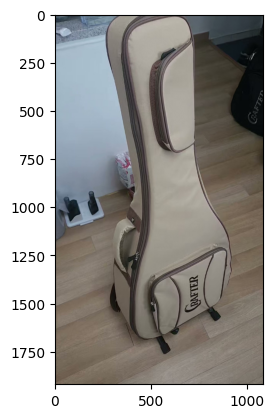

In [9]:
idx = 1 # Change it from 1 to 113
img = plt.imread(inputdir / f"{idx:04d}.jpg")
plt.imshow(img);


# Output Specifics

convert.py의 output은 중간에 COLMAP의 Mapper가 만드는 cameras, images, points3D.bin 파일들이 있고 이는

./GaussianTest/Test/distorted/sparse/0

위 경로에 저장된다.

그리고 Image Undistorter가 만드는 cameras, images, points3D.bin 파일들이 있는데 이는

./GaussianTest/Test/sparse/0

위 경로에 저장된다.

## cameras.bin 비교

Mapper의 

### cameras.bin (After Mapper)

In [79]:
f_path = './GaussianTest/Test/distorted/sparse/0/cameras.bin'
cameraData = readCamerasBin(f_path)
print("model_name:", cameraData[1]["model_name"], "\n")
# print("model_id: ")
# print(cameraData[1]["model_id"], "\n")
print("width:", cameraData[1]["width"], "\n")
print("height:", cameraData[1]["height"], "\n")
print("params:", cameraData[1]["params"], "\n")

model_name: OPENCV 

width: 1080 

height: 1920 

params: (1657.0008476436583, 1642.05678141939, 540.0, 960.0, 0.028853919820422246, -0.011796300567421926, 0.0014689788627560857, 0.003835820662421818) 



### cameras.bin (After Image Undistortion)

In [77]:
f_path = './GaussianTest/Test/sparse/0/cameras.bin'
cameraData = readCamerasBin(f_path)
print("model_name:", cameraData[1]["model_name"], "\n")
# print("model_id: ")
# print(cameraData[1]["model_id"], "\n")
print("width:", cameraData[1]["width"], "\n")
print("height:", cameraData[1]["height"], "\n")
print("params:", cameraData[1]["params"], "\n")

model_name: PINHOLE 

width: 1059 

height: 1890 

params: (1657.0008476436583, 1642.05678141939, 529.5, 945.0) 



## images.bin 비교

### images.bin 내용(After Mapper)

#### How to get data:  
f_path = './GaussianTest/Test/distorted/sparse/0/images.bin' (DO NOT CHANGE)  
imgData = readColmapImagesBin(f_path)  
  
Example: Print data for the first image  
first_image_id = list(imgData.keys())[0]  
print(imgData[first_image_id]['name'])  
print(imgData[first_image_id]['qvec'])

In [81]:
f_path = './GaussianTest/Test/distorted/sparse/0/images.bin'
imgData = readColmapImagesBin(f_path)
imgId = list(imgData.keys())[0]
#print the data of the image
print("name: ", imgData[imgId]['name'])
print("camera_id: ", imgData[imgId]['camera_id'], "\n")
print("qvec: ", imgData[imgId]['qvec'], "\n")
print("tvec: ", imgData[imgId]['tvec'], "\n")
print("xys(feature points): ")
print(imgData[imgId]['xys'], "\n")
print("point3D_ids: ", imgData[imgId]['point3D_ids'], "\n")

name:  0001.jpg
camera_id:  1 

qvec:  [0.97496518 0.03644323 0.11051639 0.18947537] 

tvec:  [ 0.31205344 -3.7165717   3.24281001] 

xys(feature points): 
[[4.92225128e+02 1.07126820e+00]
 [4.43346985e+02 2.38806248e+00]
 [4.61413910e+02 2.66591215e+00]
 ...
 [6.48481750e+02 9.17156677e+02]
 [1.06878796e+03 1.30134656e+03]
 [3.68920013e+02 1.46365564e+03]] 

point3D_ids:  [-1 -1 -1 ... -1 -1 -1] 



### 최종 images.bin 내용(After Image Undistortion)

In [82]:
f_path = './GaussianTest/Test/sparse/0/images.bin'
imgData = readColmapImagesBin(f_path)
imgId = list(imgData.keys())[0]
# print the data of the image
print("name: ", imgData[imgId]['name'])
print("camera_id: ", imgData[imgId]['camera_id'])
print("qvec: ", imgData[imgId]['qvec'], "\n")
print("tvec: ", imgData[imgId]['tvec'], "\n")
print("xys(feature points): ")
print(imgData[imgId]['xys'], "\n")
print("point3D_ids: ", imgData[imgId]['point3D_ids'], "\n")


name:  0001.jpg
camera_id:  1
qvec:  [0.97496518 0.03644323 0.11051639 0.18947537] 

tvec:  [ 0.31205344 -3.7165717   3.24281001] 

xys(feature points): 
[[ 479.89701257   -8.57291651]
 [ 431.30363594   -7.44406146]
 [ 449.27088813   -7.11296834]
 ...
 [ 637.88866657  902.16904257]
 [1053.75932193 1283.66271821]
 [ 358.26880459 1446.90820833]] 

point3D_ids:  [-1 -1 -1 ... -1 -1 -1] 



## points3D.bin 비교

### points3D.bin 내용(After Mapper)

#### How to get data(ex.)
file_path = './GaussianTest/Test/sparse/0/points3D.bin'  
points_data = read_colmap_points3D_bin(file_path)  
  
Example: Get the XYZ coordinate of the first point in the dictionary  
first_point_id = list(points_data.keys())[0]  
print("XYZ:", points_data[first_point_id]['xyz'])  
print("RGB:", points_data[first_point_id]['rgb'])

In [84]:
f_path = './GaussianTest/Test/distorted/sparse/0/points3D.bin'
pts3DData = readColmapPoints3DBin(f_path)
point3DId = list(pts3DData.keys())[i]
# print the data of the 3D point
print("id: ", pts3DData[point3DId]['id'])
print("xyz: ", pts3DData[point3DId]['xyz'], "\n")
print("rgb: ", pts3DData[point3DId]['rgb'], "\n")
print("error: ", pts3DData[point3DId]['error'], "\n")
print("image_ids: ", pts3DData[point3DId]['image_ids'], "\n")
print("point2D_idxs: ", pts3DData[point3DId]['point2D_idxs'], "\n")

id:  3515
xyz:  [1.85526479 8.2249565  7.06847494] 

rgb:  [27 23 12] 

error:  1.0977645117098063 

image_ids:  [107 110 104 113] 

point2D_idxs:  [2906 4585  790 3713] 



### 최종 points3D.bin 내용(After Image Undistortion)

In [86]:
f_path = './GaussianTest/Test/sparse/0/points3D.bin'
pts3DData = readColmapPoints3DBin(f_path)
point3DId = list(pts3DData.keys())[i]
# print the data of the 3D point
print("id: ", pts3DData[point3DId]['id'])
print("xyz: ", pts3DData[point3DId]['xyz'], "\n")
print("rgb: ", pts3DData[point3DId]['rgb'], "\n")
print("error: ", pts3DData[point3DId]['error'], "\n")
print("image_ids: ", pts3DData[point3DId]['image_ids'], "\n")
print("point2D_idxs: ", pts3DData[point3DId]['point2D_idxs'], "\n")
    

id:  6
xyz:  [4.28537623 1.22670948 9.68768406] 

rgb:  [113 115 128] 

error:  0.9746778054994051 

image_ids:  [102  86 100 106 103 101  85  87] 

point2D_idxs:  [4174 1381 4199 3669 5399 4449 2685 1829] 



# 장기적 TODO:

* 본인이 찍은 기타 사진
  * 작은 image set으로 추려서 로컬에서 실행
  * image set 전체 세라프 실행
* gaussian splatting에 많이 쓰이는 공개 image set도 세라프로 실행
* 공개된 set, 본인이 찍은 set 양쪽 다 3dGS계열 최신 논문 찾아서 설치해서 실행해서 비교해보기